In [1]:
#setup-imports-and-paths
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import qutip as qt

from IPython.display import display, Math

#project-root-path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

#figures-folder-path
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

#outputs-folder-path
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figures folder:", FIGURES_DIR)
print("Outputs folder:", OUTPUTS_DIR)
print("Notebook setup complete.")

Project root: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project
Figures folder: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures
Outputs folder: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\outputs
Notebook setup complete.


In [2]:
#latex-physical-setup-gamma0-effects
display(Math(r"L_c = \sqrt{\Gamma_c}\,J_-"))
display(Math(r"J_-=\sum_i \sigma_-^i"))
display(Math(r"L_i = \sqrt{\Gamma_0}\,\sigma_-^i"))
display(Math(r"P_e(t)=\sum_i \langle \sigma^i_{ee}(t)\rangle"))
display(Math(r"R(t)=-\frac{dP_e(t)}{dt}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
#Gamma_c gives collective cavity decay.
#Gamma_0 gives independent free-space decay.
#As Gamma_0 becomes comparable to Gamma_c, independent decay competes with the collective channel.

In [5]:
#physical-parameters-gamma0-sweep
gammac = 1.0

#gamma0-over-gammac-values-parameter
gamma0_ratios = [0.0, 0.05, 0.1, 0.5, 1.0, 2.0]

#atom-number-for-main-comparison
num_atoms = 6

#time-grid-dimensionless-time-s-gammac-t
s_min = 0.0
s_max = 3.0
num_points = 500
s_grid = np.linspace(s_min, s_max, num_points)

#physical-time-grid-t=s/gammac
t_grid = s_grid / gammac

print("gammac =", gammac)
print("gamma0/gammac values =", gamma0_ratios)
print("N =", num_atoms)
print("Using dimensionless time s = Gamma_c t")

gammac = 1.0
gamma0/gammac values = [0.0, 0.05, 0.1, 0.5, 1.0, 2.0]
N = 6
Using dimensionless time s = Gamma_c t


In [19]:
#N10-gamma0-effects-test
num_atoms_N10 = 10

#lighter-time-grid-for-N10
s_grid_N10 = np.linspace(0.0, 3.0, 300)
t_grid_N10 = s_grid_N10 / gammac

#start-with-core-ratios
gamma0_ratios_N10 = [0.0, 0.1, 0.5, 1.0, 2.0]

print("N =", num_atoms_N10)
print("time points =", len(t_grid_N10))
print("gamma0/gammac values =", gamma0_ratios_N10)

N = 10
time points = 300
gamma0/gammac values = [0.0, 0.1, 0.5, 1.0, 2.0]


In [6]:
#single-atom-basis-and-operators-qutip
ket_e_single = qt.basis(2, 0)
ket_g_single = qt.basis(2, 1)

#sigma-minus-single-atom-lowering-operator-calc
sigma_minus_single = ket_g_single * ket_e_single.dag()

#sigma-plus-single-atom-raising-operator-calc
sigma_plus_single = sigma_minus_single.dag()

#sigma-ee-single-atom-excited-population-operator-calc
sigma_ee_single = ket_e_single * ket_e_single.dag()

#identity-single-atom-operator-calc
identity_single = qt.qeye(2)

print("sigma_minus_single:")
print(sigma_minus_single)

print("sigma_ee_single:")
print(sigma_ee_single)

sigma_minus_single:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. 0.]
 [1. 0.]]
sigma_ee_single:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]]


In [7]:
#many-atom-local-operator-builder
def local_operator(single_atom_operator, atom_index, num_atoms):
    """
    #local-operator-calc
    Places a single-atom operator on one atom and identities on all other atoms.
    """
    
    #operator-list-calc
    operator_list = []
    
    for index in range(num_atoms):
        if index == atom_index:
            operator_list.append(single_atom_operator)
        else:
            operator_list.append(identity_single)
    
    #tensor-product-calc
    return qt.tensor(operator_list)

In [8]:
#many-atom-operators-builder
def build_many_atom_operators(num_atoms):
    """
    #many-atom-operators-calc
    Builds local lowering operators, local excited-state projectors,
    collective lowering operator, total excited population operator,
    and the all-excited initial state.
    """
    
    #local-lowering-operators-storage-calc
    sigma_minus_ops = [
        local_operator(sigma_minus_single, atom_index, num_atoms)
        for atom_index in range(num_atoms)
    ]
    
    #local-excited-population-operators-storage-calc
    sigma_ee_ops = [
        local_operator(sigma_ee_single, atom_index, num_atoms)
        for atom_index in range(num_atoms)
    ]
    
    #collective-lowering-operator-calc
    J_minus = sum(sigma_minus_ops)
    
    #total-excited-population-operator-calc
    total_excited_population_operator = sum(sigma_ee_ops)
    
    #initial-state-all-atoms-excited-calc
    psi0 = qt.tensor([ket_e_single for _ in range(num_atoms)])
    
    #initial-density-matrix-calc
    rho0 = psi0 * psi0.dag()
    
    return {
        "sigma_minus_ops": sigma_minus_ops,
        "sigma_ee_ops": sigma_ee_ops,
        "J_minus": J_minus,
        "total_excited_population_operator": total_excited_population_operator,
        "psi0": psi0,
        "rho0": rho0,
    }

In [9]:
#collapse-operators-builder
def build_collapse_operators(num_atoms, gamma0, gammac):
    """
    #collapse-operators-calc
    Builds collapse operators for collective cavity decay and independent free-space decay.

    #collective-cavity-decay
    L_c = sqrt(gammac) J_minus

    #independent-free-space-decay
    L_i = sqrt(gamma0) sigma_minus_i
    """
    
    #many-atom-operators-calc
    operators = build_many_atom_operators(num_atoms)
    
    #collapse-operators-storage-calc
    collapse_operators = []
    
    if gammac > 0:
        #collective-cavity-jump-operator-calc
        L_cavity = np.sqrt(gammac) * operators["J_minus"]
        collapse_operators.append(L_cavity)
    
    if gamma0 > 0:
        for sigma_minus_i in operators["sigma_minus_ops"]:
            #free-space-jump-operator-calc
            L_free_i = np.sqrt(gamma0) * sigma_minus_i
            collapse_operators.append(L_free_i)
    
    return collapse_operators

In [10]:
#solve-many-atom-master-equation-function
def solve_many_atom_master_equation(num_atoms, gamma0, gammac, t_grid):
    """
    #many-atom-master-equation-solver
    Solves the full Hilbert-space Lindblad master equation for N atoms.

    #output
    Returns total excited-state population P_e(t).
    """
    
    #many-atom-operators-calc
    operators = build_many_atom_operators(num_atoms)
    
    #hamiltonian-zero-because-resonant-no-hamiltonian-term
    H = 0 * qt.qeye([2 for _ in range(num_atoms)])
    
    #collapse-operators-calc
    collapse_operators = build_collapse_operators(num_atoms, gamma0, gammac)
    
    #expectation-operator-total-excited-population
    e_ops = [operators["total_excited_population_operator"]]
    
    print(f"Solving N = {num_atoms}, gamma0/gammac = {gamma0/gammac if gammac != 0 else np.nan}")
    print(f"Hilbert dimension d = {2 ** num_atoms}")
    print(f"Number of collapse operators = {len(collapse_operators)}")
    
    #master-equation-solver-calc
    result = qt.mesolve(
        H,
        operators["rho0"],
        t_grid,
        collapse_operators,
        e_ops,
    )
    
    #total-excited-population-calc
    total_excited_population = np.real(result.expect[0])
    
    return total_excited_population

In [11]:
#solve-gamma0-ratio-sweep
population_by_ratio = {}
runtime_rows = []

for ratio in gamma0_ratios:
    
    #gamma0-current-parameter
    gamma0 = ratio * gammac
    
    start_time = time.time()
    
    population = solve_many_atom_master_equation(
        num_atoms=num_atoms,
        gamma0=gamma0,
        gammac=gammac,
        t_grid=t_grid,
    )
    
    elapsed_time = time.time() - start_time
    
    population_by_ratio[ratio] = population
    
    runtime_rows.append({
        "N": num_atoms,
        "gamma0/gammac": ratio,
        "runtime seconds": elapsed_time,
        "initial population": population[0],
        "final population": population[-1],
    })
    
    print(f"Finished gamma0/gammac = {ratio} in {elapsed_time:.2f} seconds")

runtime_table = pd.DataFrame(runtime_rows)
runtime_table

Solving N = 6, gamma0/gammac = 0.0
Hilbert dimension d = 64
Number of collapse operators = 1
Finished gamma0/gammac = 0.0 in 0.11 seconds
Solving N = 6, gamma0/gammac = 0.05
Hilbert dimension d = 64
Number of collapse operators = 7
Finished gamma0/gammac = 0.05 in 0.07 seconds
Solving N = 6, gamma0/gammac = 0.1
Hilbert dimension d = 64
Number of collapse operators = 7


C:\Users\ivraa\miniforge31\envs\optics-me\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Finished gamma0/gammac = 0.1 in 0.12 seconds
Solving N = 6, gamma0/gammac = 0.5
Hilbert dimension d = 64
Number of collapse operators = 7
Finished gamma0/gammac = 0.5 in 0.11 seconds
Solving N = 6, gamma0/gammac = 1.0
Hilbert dimension d = 64
Number of collapse operators = 7
Finished gamma0/gammac = 1.0 in 0.07 seconds
Solving N = 6, gamma0/gammac = 2.0
Hilbert dimension d = 64
Number of collapse operators = 7
Finished gamma0/gammac = 2.0 in 0.14 seconds


,N,gamma0/gammac,runtime seconds,initial population,final population
0,6,0.00,0.109251,6.0,0.000006
1,6,0.05,0.065996,6.0,0.063443
2,6,0.10,0.115344,6.0,0.110631
3,6,0.50,0.106600,6.0,0.170868
4,6,1.00,0.072647,6.0,0.071260
5,6,2.00,0.135243,6.0,0.005801


In [12]:
#compute-emission-rate-from-population
emission_rate_by_ratio = {}

for ratio, population in population_by_ratio.items():
    
    #rate-negative-derivative-calc
    emission_rate = -np.gradient(population, t_grid)
    
    emission_rate_by_ratio[ratio] = emission_rate

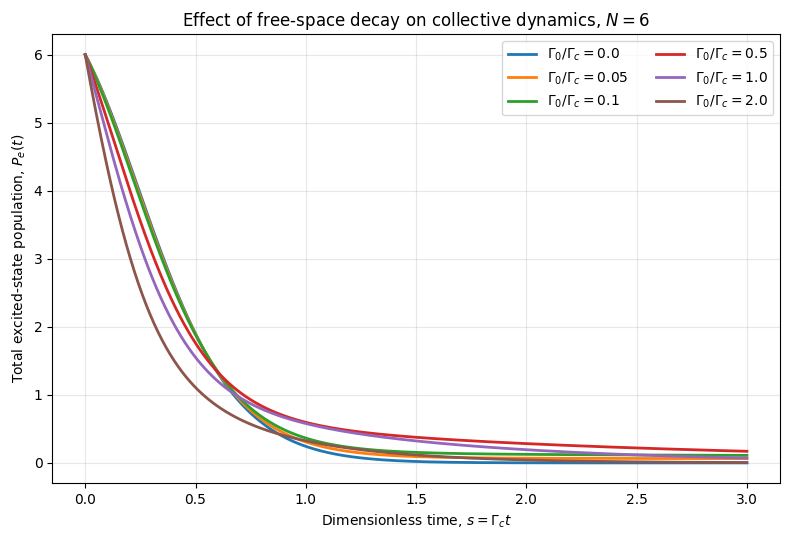

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\gamma0_effect_total_population_N6.png


In [13]:
#plot-population-vs-gamma0-ratio
plt.figure(figsize=(8, 5.5))

for ratio in gamma0_ratios:
    plt.plot(
        s_grid,
        population_by_ratio[ratio],
        linewidth=2,
        label=rf"$\Gamma_0/\Gamma_c={ratio}$",
    )

plt.xlabel(r"Dimensionless time, $s=\Gamma_c t$")
plt.ylabel(r"Total excited-state population, $P_e(t)$")
plt.title(rf"Effect of free-space decay on collective dynamics, $N={num_atoms}$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

figure_path = FIGURES_DIR / f"gamma0_effect_total_population_N{num_atoms}.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

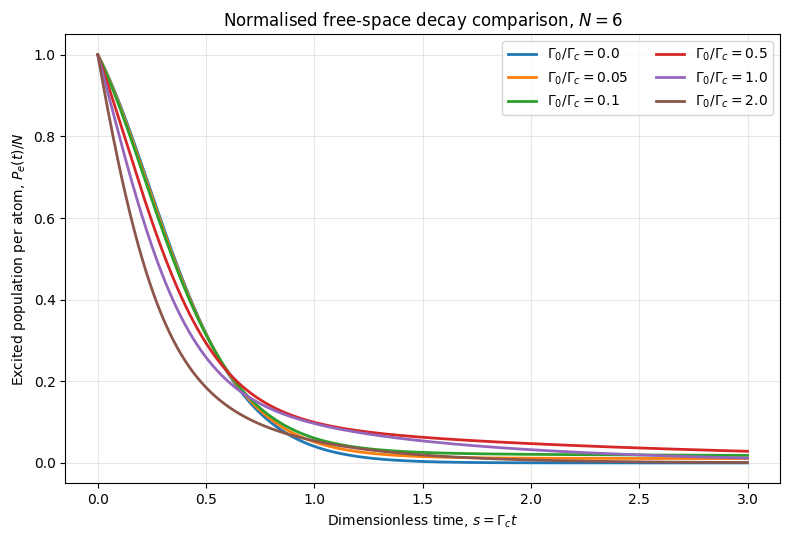

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\gamma0_effect_normalised_population_N6.png


In [14]:
#plot-normalised-population-vs-gamma0-ratio
plt.figure(figsize=(8, 5.5))

for ratio in gamma0_ratios:
    plt.plot(
        s_grid,
        population_by_ratio[ratio] / num_atoms,
        linewidth=2,
        label=rf"$\Gamma_0/\Gamma_c={ratio}$",
    )

plt.xlabel(r"Dimensionless time, $s=\Gamma_c t$")
plt.ylabel(r"Excited population per atom, $P_e(t)/N$")
plt.title(rf"Normalised free-space decay comparison, $N={num_atoms}$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

figure_path = FIGURES_DIR / f"gamma0_effect_normalised_population_N{num_atoms}.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

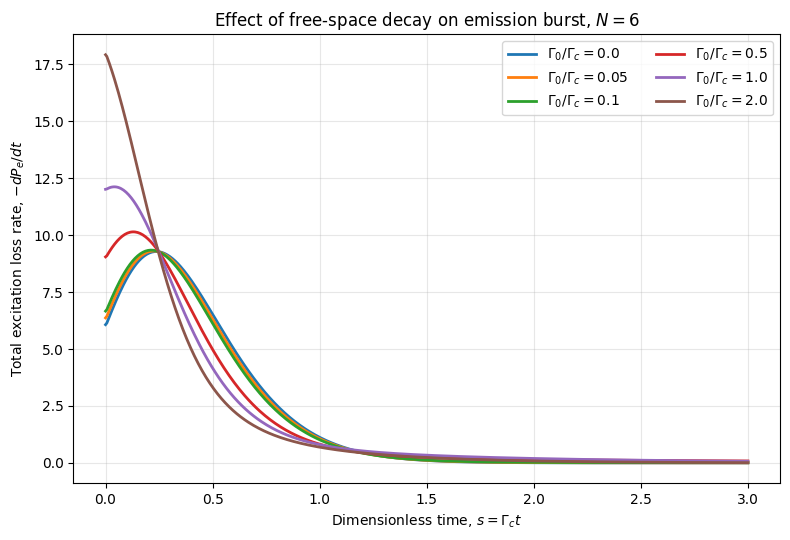

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\gamma0_effect_total_decay_rate_N6.png


In [15]:
#plot-total-decay-rate-vs-gamma0-ratio
plt.figure(figsize=(8, 5.5))

for ratio in gamma0_ratios:
    plt.plot(
        s_grid,
        emission_rate_by_ratio[ratio],
        linewidth=2,
        label=rf"$\Gamma_0/\Gamma_c={ratio}$",
    )

plt.xlabel(r"Dimensionless time, $s=\Gamma_c t$")
plt.ylabel(r"Total excitation loss rate, $-dP_e/dt$")
plt.title(rf"Effect of free-space decay on emission burst, $N={num_atoms}$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

figure_path = FIGURES_DIR / f"gamma0_effect_total_decay_rate_N{num_atoms}.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [16]:
#extract-gamma0-effect-peak-data
peak_rows = []

for ratio in gamma0_ratios:
    
    rate = emission_rate_by_ratio[ratio]
    
    #peak-index-calc
    peak_index = np.argmax(rate)
    
    #peak-rate-calc
    peak_rate = rate[peak_index]
    
    #peak-time-calc
    peak_time = s_grid[peak_index]
    
    peak_rows.append({
        "gamma0/gammac": ratio,
        "peak total excitation loss rate": peak_rate,
        "peak time Gamma_c t": peak_time,
        "peak rate per atom": peak_rate / num_atoms,
    })

peak_table = pd.DataFrame(peak_rows)

peak_csv_path = OUTPUTS_DIR / f"gamma0_effect_peak_table_N{num_atoms}.csv"
peak_table.to_csv(peak_csv_path, index=False)

print("Saved peak table to:", peak_csv_path)
peak_table

Saved peak table to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\outputs\gamma0_effect_peak_table_N6.csv


,gamma0/gammac,peak total excitation loss rate,peak time Gamma_c t,peak rate per atom
0,0.00,9.284113,0.234469,1.547352
1,0.05,9.306959,0.222445,1.551160
2,0.10,9.346059,0.210421,1.557676
3,0.50,10.147424,0.132265,1.691237
4,1.00,12.125483,0.042084,2.020914
5,2.00,17.926843,0.000000,2.987807


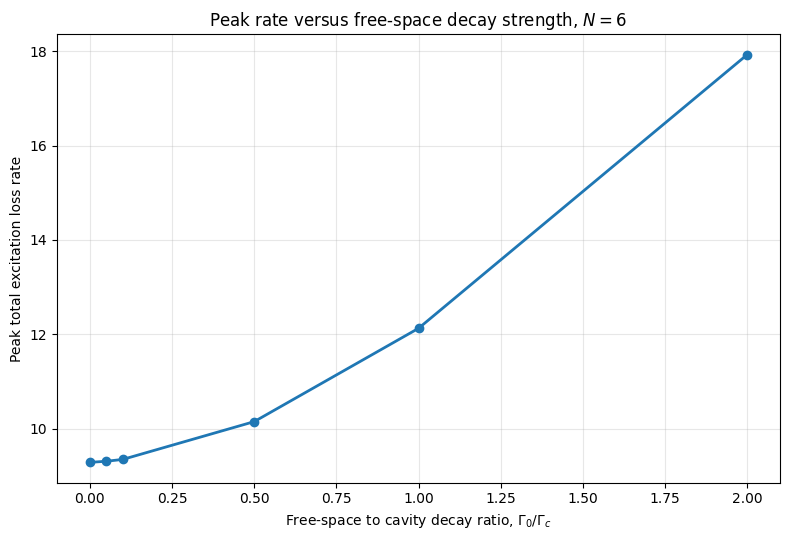

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\gamma0_effect_peak_rate_vs_ratio_N6.png


In [17]:
#plot-peak-rate-vs-gamma0-ratio
plt.figure(figsize=(8, 5.5))

plt.plot(
    peak_table["gamma0/gammac"],
    peak_table["peak total excitation loss rate"],
    marker="o",
    linewidth=2,
)

plt.xlabel(r"Free-space to cavity decay ratio, $\Gamma_0/\Gamma_c$")
plt.ylabel(r"Peak total excitation loss rate")
plt.title(rf"Peak rate versus free-space decay strength, $N={num_atoms}$")
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / f"gamma0_effect_peak_rate_vs_ratio_N{num_atoms}.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [18]:
#report-note-gamma0-effects
print(
    "When Gamma_0 is zero, the atoms decay only through the collective cavity channel. "
    "The system can build collective Dicke enhancement, producing a delayed non-monotonic burst "
    "in the excitation loss rate. When Gamma_0 is nonzero, each atom also has an independent "
    "free-space decay channel. This independent decay removes excitations before they can fully "
    "participate in the collective cavity-mediated emission. As Gamma_0 becomes comparable to "
    "Gamma_c, the collective burst is weakened and the dynamics becomes closer to independent "
    "single-atom decay. For large Gamma_0/Gamma_c, free-space decay dominates and washes out the "
    "cooperative character of the cavity emission."
)

When Gamma_0 is zero, the atoms decay only through the collective cavity channel. The system can build collective Dicke enhancement, producing a delayed non-monotonic burst in the excitation loss rate. When Gamma_0 is nonzero, each atom also has an independent free-space decay channel. This independent decay removes excitations before they can fully participate in the collective cavity-mediated emission. As Gamma_0 becomes comparable to Gamma_c, the collective burst is weakened and the dynamics becomes closer to independent single-atom decay. For large Gamma_0/Gamma_c, free-space decay dominates and washes out the cooperative character of the cavity emission.


In [20]:
#solve-N10-gamma0-ratio-sweep
population_by_ratio_N10 = {}
runtime_rows_N10 = []

for ratio in gamma0_ratios_N10:
    
    #gamma0-current-parameter
    gamma0_current = ratio * gammac
    
    start_time = time.time()
    
    try:
        population = solve_many_atom_master_equation(
            num_atoms=num_atoms_N10,
            gamma0=gamma0_current,
            gammac=gammac,
            t_grid=t_grid_N10,
        )
        
        elapsed_time = time.time() - start_time
        
        population_by_ratio_N10[ratio] = population
        
        runtime_rows_N10.append({
            "N": num_atoms_N10,
            "gamma0/gammac": ratio,
            "runtime seconds": elapsed_time,
            "initial population": population[0],
            "final population": population[-1],
            "status": "completed",
        })
        
        #save-immediately-calc
        np.save(
            OUTPUTS_DIR / f"gamma0_effect_population_N10_ratio_{ratio}.npy",
            population,
        )
        
        print(f"Finished N=10, gamma0/gammac={ratio} in {elapsed_time:.2f} seconds")
    
    except Exception as error:
        elapsed_time = time.time() - start_time
        
        runtime_rows_N10.append({
            "N": num_atoms_N10,
            "gamma0/gammac": ratio,
            "runtime seconds": elapsed_time,
            "initial population": np.nan,
            "final population": np.nan,
            "status": f"failed: {type(error).__name__}",
        })
        
        print(f"Failed N=10, gamma0/gammac={ratio} after {elapsed_time:.2f} seconds")
        print("Error:", error)
        break

runtime_table_N10 = pd.DataFrame(runtime_rows_N10)
runtime_table_N10

Solving N = 10, gamma0/gammac = 0.0
Hilbert dimension d = 1024
Number of collapse operators = 1


C:\Users\ivraa\miniforge31\envs\optics-me\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Finished N=10, gamma0/gammac=0.0 in 81.43 seconds
Solving N = 10, gamma0/gammac = 0.1
Hilbert dimension d = 1024
Number of collapse operators = 11
Finished N=10, gamma0/gammac=0.1 in 134.89 seconds
Solving N = 10, gamma0/gammac = 0.5
Hilbert dimension d = 1024
Number of collapse operators = 11
Finished N=10, gamma0/gammac=0.5 in 198.33 seconds
Solving N = 10, gamma0/gammac = 1.0
Hilbert dimension d = 1024
Number of collapse operators = 11
Finished N=10, gamma0/gammac=1.0 in 200.65 seconds
Solving N = 10, gamma0/gammac = 2.0
Hilbert dimension d = 1024
Number of collapse operators = 11
Finished N=10, gamma0/gammac=2.0 in 221.87 seconds


,N,gamma0/gammac,runtime seconds,initial population,final population,status
0,10,0.0,81.430331,10.0,4.740375e-10,completed
1,10,0.1,134.886156,10.0,1.469952e-01,completed
2,10,0.5,198.332525,10.0,2.398784e-01,completed
3,10,1.0,200.647848,10.0,1.080079e-01,completed
4,10,2.0,221.873986,10.0,9.552777e-03,completed


In [21]:
#compute-N10-emission-rate-from-population
emission_rate_by_ratio_N10 = {}

for ratio, population in population_by_ratio_N10.items():
    
    #total-excitation-loss-rate-calc
    emission_rate = -np.gradient(population, t_grid_N10)
    
    emission_rate_by_ratio_N10[ratio] = emission_rate

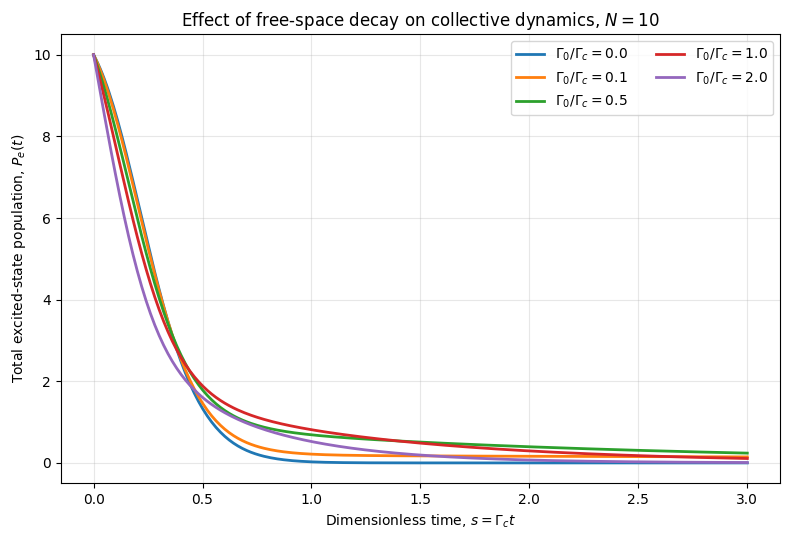

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\gamma0_effect_total_population_N10.png


In [22]:
#plot-N10-population-vs-gamma0-ratio
plt.figure(figsize=(8, 5.5))

for ratio in gamma0_ratios_N10:
    if ratio in population_by_ratio_N10:
        plt.plot(
            s_grid_N10,
            population_by_ratio_N10[ratio],
            linewidth=2,
            label=rf"$\Gamma_0/\Gamma_c={ratio}$",
        )

plt.xlabel(r"Dimensionless time, $s=\Gamma_c t$")
plt.ylabel(r"Total excited-state population, $P_e(t)$")
plt.title(r"Effect of free-space decay on collective dynamics, $N=10$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

figure_path = FIGURES_DIR / "gamma0_effect_total_population_N10.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

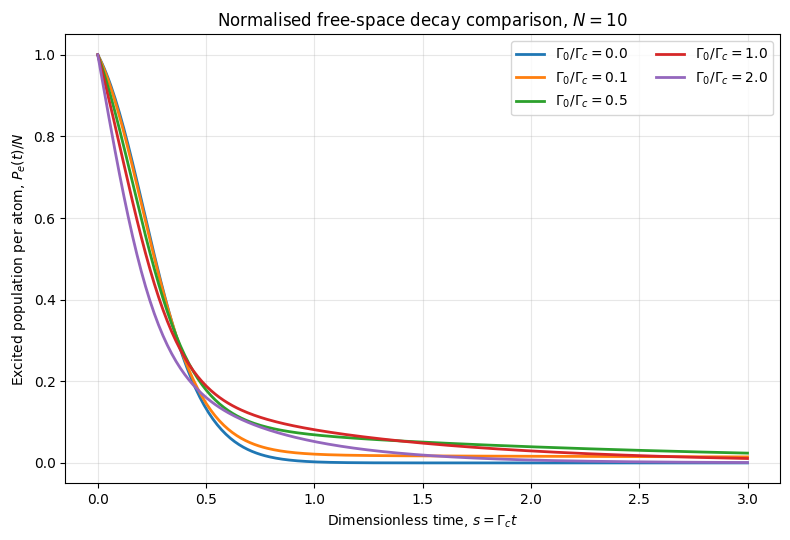

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\gamma0_effect_normalised_population_N10.png


In [23]:
#plot-N10-normalised-population-vs-gamma0-ratio
plt.figure(figsize=(8, 5.5))

for ratio in gamma0_ratios_N10:
    if ratio in population_by_ratio_N10:
        plt.plot(
            s_grid_N10,
            population_by_ratio_N10[ratio] / num_atoms_N10,
            linewidth=2,
            label=rf"$\Gamma_0/\Gamma_c={ratio}$",
        )

plt.xlabel(r"Dimensionless time, $s=\Gamma_c t$")
plt.ylabel(r"Excited population per atom, $P_e(t)/N$")
plt.title(r"Normalised free-space decay comparison, $N=10$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

figure_path = FIGURES_DIR / "gamma0_effect_normalised_population_N10.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

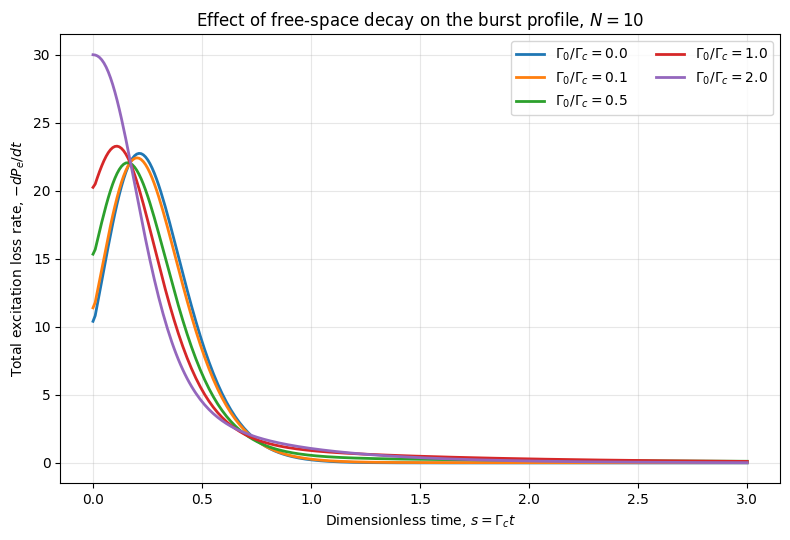

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\gamma0_effect_total_decay_rate_N10.png


In [24]:
#plot-N10-total-decay-rate-vs-gamma0-ratio
plt.figure(figsize=(8, 5.5))

for ratio in gamma0_ratios_N10:
    if ratio in emission_rate_by_ratio_N10:
        plt.plot(
            s_grid_N10,
            emission_rate_by_ratio_N10[ratio],
            linewidth=2,
            label=rf"$\Gamma_0/\Gamma_c={ratio}$",
        )

plt.xlabel(r"Dimensionless time, $s=\Gamma_c t$")
plt.ylabel(r"Total excitation loss rate, $-dP_e/dt$")
plt.title(r"Effect of free-space decay on the burst profile, $N=10$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

figure_path = FIGURES_DIR / "gamma0_effect_total_decay_rate_N10.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [25]:
#save-N10-gamma0-effects-runtime-table
runtime_csv_path_N10 = OUTPUTS_DIR / "gamma0_effect_runtime_table_N10.csv"
runtime_table_N10.to_csv(runtime_csv_path_N10, index=False)

print("Saved N=10 runtime table to:", runtime_csv_path_N10)
runtime_table_N10

Saved N=10 runtime table to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\outputs\gamma0_effect_runtime_table_N10.csv


,N,gamma0/gammac,runtime seconds,initial population,final population,status
0,10,0.0,81.430331,10.0,4.740375e-10,completed
1,10,0.1,134.886156,10.0,1.469952e-01,completed
2,10,0.5,198.332525,10.0,2.398784e-01,completed
3,10,1.0,200.647848,10.0,1.080079e-01,completed
4,10,2.0,221.873986,10.0,9.552777e-03,completed


In [ ]:
#plot max rate over gamma_0/gammac